### Add Name: Coen van den Burg

### Add Student Number: s5363241

# Assignment 1: Time-series data

**The use of generative AI is not allowed** 

**Objective**
The goal of this assignment is to develop an understanding of how trajectory data can be analyzed in both the time domain (using Autocorrelation) and the frequency domain (using Periodograms).
Refer **Lecture 2**. 

You will learn:

-Learn how trajectory data is recorded and tracked.

-Simulate synthetic trajectory data with realistic imperfections (e.g., noise, missing points, irregularities).

-Apply autocorrelation and periodogram methods to analyze patterns in the simulated data.

-Extend the analysis to real-life trajectory data and interpret results.


**This assignment consists of five parts:**

SECTION I

1. Create synthetic data to test the algorithm you design.
2. Write two functions:
    - autocorrelation.
    - period extraction function.
3. Use a periodogram function.
4. Compare the sensitivity of the algorithms to typical imperfections occur in real data (noise, missing data, random and non-periodic patterns).

SECTION II

Test the algorithms on geolife data.

5. Try handling missing values , apply the autocorrelation and periodogram, explain your findings.
   
 


**WARNING: Make sure to read through the entire assignment before starting to code. The tasks build on each other!**

Good luck with the assignment! Deadline is **September 29th, at 23:59** hrs. Please push your code to the GitHub classroom before the deadline. **Make sure to read the *"Submission procedure"* section in the *"README.md"* file to ensure reproducibility.**


## 0th part: Prerequisites
Please add any packages you use to the code cell below.

In [80]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.signal import periodogram, find_peaks


# etc.



## 1st part: Create Synthetic Data

Imagine that you have a GPS device that takes a measurement every 1 hr. Create a synthetic data trajectory with two periodicities for 365 days. Consider the time interval of records to be 1 hr. For ex: consider from point A to point B , it takes 60 mins to travel.  The trajectory data should include two types of periodicities (e.g., one daily and one weekly). For example, you can take your home-Snellius trajectory as a daily trajectory repeating from Monday to Friday (daily period) and your weekly trip to the supermarket or city center from home during the weekend as the second one (weekly period). Assume that you have a regular schedule (e.g. leaving every day at 8 and returning at 5). Simulate the whole trajectory (the path and the time you spend in each place). You can find GPS locations via Google Maps (right-click on map - what is here?) or any other online map service. Try to think of scenarios that make this data as accurate as possible. You can be creative about your home location because that's private information!

The GPS location of the entrance of the Snellius building is: 52.169709, 4.457111. 

Use a constant time between waypoints / GPS locations for this exercise.

Tip I : a periodicity of 24 is a recurring event every 24 hrs (i.e. a daily event), a periodicity of 168 hrs is a weekly event.

Tip II: We talked so far about processing one time series. In case two time-series acquired from two coordinates is difficult to handle, try to use only one, or combine them into one value (e.g. sqrt(lat^2 + long^2)).

Tip III: Stuck with how to simulate data? Check the Lab of the first week and get some inspiration there.

In [55]:
# simulate data in form of two timeseries latitude and longitude of length (24*365):
def simulate(home_coord, supermarket_coord, snellius_coord):
    #generate hourly timestamps for 365 days (24 * 365 = 8760 periods)
    time_index = pd.date_range(start='2026-01-01 00:00:00', periods=24 * 365, freq='h')
    
    #create a temporary DataFrame to extract temporal features
    df = pd.DataFrame(index=time_index)
    df['hour'] = df.index.hour
    df['day_of_week'] = df.index.dayofweek  # 0 = Monday, 6 = Sunday
    df['is_weekend'] = df['day_of_week'].isin([5, 6])
    
    #define conditions based on schedule
    #weekdays from 08:00 to 17:00 at Snellius
    is_weekday = df['day_of_week'] < 5
    is_work_hours = (df['hour'] >= 8) & (df['hour'] <= 17)
    at_snellius = is_weekday & is_work_hours
    
    #weekends from 13:00 to 14:00 at the Supermarket
    at_supermarket = df['is_weekend'] & (df['hour'] >= 13) & (df['hour'] <= 14)
    #otherwise at home

    #map conditions to latitude and longitude choices
    lat_choices = [snellius_coord[0], supermarket_coord[0]]
    lon_choices = [snellius_coord[1], supermarket_coord[1]]
    conditions = [at_snellius, at_supermarket]
    
    latitudes = np.select(conditions, lat_choices, default=home_coord[0])
    longitudes = np.select(conditions, lon_choices, default=home_coord[1])

    combined_coords = []
    for lats, longs in zip(latitudes, longitudes):
        combined_coords.append((lats**2 + longs**2)**0.5)

    #final simulated data structure
    simulated_data = pd.DataFrame({
        'latitude': latitudes,
        'longitude': longitudes,
        'combined': combined_coords
    }, index=time_index)
    
    return simulated_data

In [56]:
home_coord = (52.25858953977117, 4.563226964373498)  # busstop Nassaupark Lisse (south side)
supermarket_coord = (52.261810545199886, 4.559651730489068)  # Albert Heijn Lisse)
snellius_coord = (52.169709, 4.457111)  # Snellius building

In [57]:
result_df = simulate(home_coord, supermarket_coord, snellius_coord)
print(result_df.head(25)) #first 24 hours

                      latitude  longitude   combined
2026-01-01 00:00:00  52.258590   4.563227  52.457442
2026-01-01 01:00:00  52.258590   4.563227  52.457442
2026-01-01 02:00:00  52.258590   4.563227  52.457442
2026-01-01 03:00:00  52.258590   4.563227  52.457442
2026-01-01 04:00:00  52.258590   4.563227  52.457442
2026-01-01 05:00:00  52.258590   4.563227  52.457442
2026-01-01 06:00:00  52.258590   4.563227  52.457442
2026-01-01 07:00:00  52.258590   4.563227  52.457442
2026-01-01 08:00:00  52.169709   4.457111  52.359759
2026-01-01 09:00:00  52.169709   4.457111  52.359759
2026-01-01 10:00:00  52.169709   4.457111  52.359759
2026-01-01 11:00:00  52.169709   4.457111  52.359759
2026-01-01 12:00:00  52.169709   4.457111  52.359759
2026-01-01 13:00:00  52.169709   4.457111  52.359759
2026-01-01 14:00:00  52.169709   4.457111  52.359759
2026-01-01 15:00:00  52.169709   4.457111  52.359759
2026-01-01 16:00:00  52.169709   4.457111  52.359759
2026-01-01 17:00:00  52.169709   4.457111  52.

## 2nd part: Write two functions

Your task is to write:

 1. A function that performs an [autocorrelation](https://en.wikipedia.org/wiki/Autocorrelation) (Lecture slide 20) on the synthetic data and returns the correlation value and corresponding delay for every possible delay. Note: you have to write this function yourself. You will not get points if you use a ready-to-use autocorrelation function from a library.

 2. A visualisation of the autocorrelation function that shows the correlation value as a function of the delay. The quality of the graph will also be graded (e.g., axes labels). 
 3. A function that evaluates the output of the autocorrelation function and manages to extract the two simulated periodicities i.e (24, 168) as output and indicate which periodicity is more prominent (i.e frequent). 
 
Tip I: In case of autocorrelaton function, you can implement a circular version(shifting values from the end of time-series to its begining).

Tip II:  If your function takes too much time to run, you can also check out vectorized operations by Numpy or scipy.

Tip III: For guidance on implementing the autocorrelation function and visualizing its results, refer to the paper (“**Recognition of Periodic Behavioral Patterns from Streaming Mobility Data**”) cited in **Lecture Slide 22**.




In [58]:
#correct
def autocorrelation(data):
    T = len(data)
    mean_val = sum(data) / T
    
    autocorr = {}
    for tau in range(T):
        summation = 0.0
        #looping through the entire length T using modulo to wrap around
        for t in range(T):
            summation += (data[t] - mean_val) * (data[(t + tau) % T] - mean_val)
            
        acf_value = (1 / T) * summation
        autocorr[tau] = acf_value
        
    return autocorr

In [59]:
#generate ACF values for all possible tau values
autocorr = autocorrelation(result_df['combined'].tolist())
#print(autocorr)

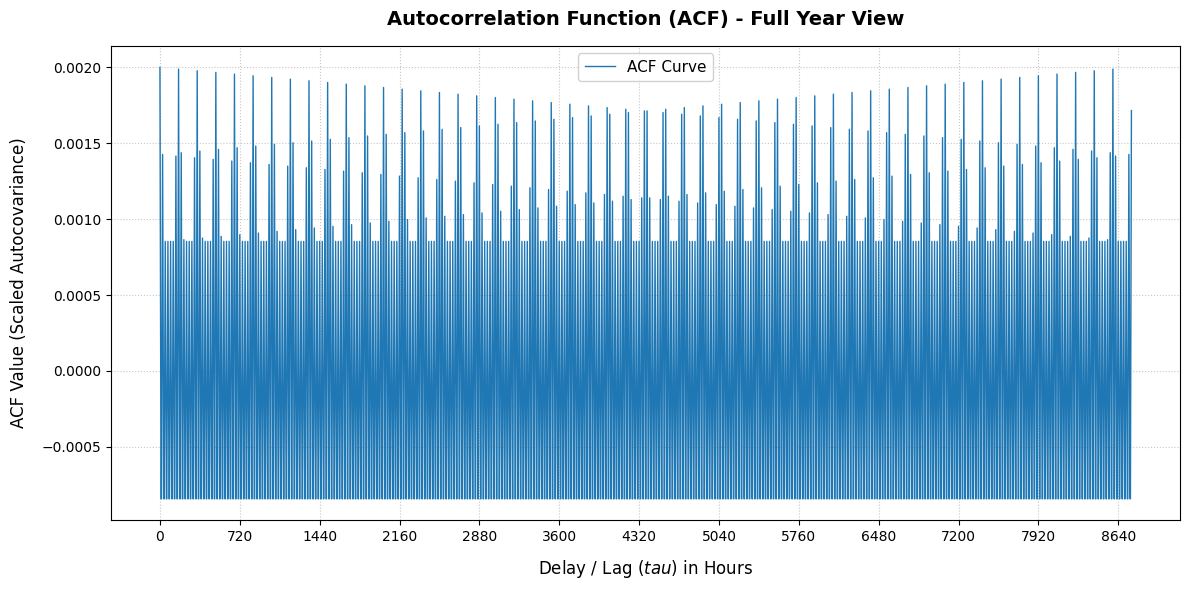

In [60]:
#plot 1: Full Year View
# display ACF on y-axis, time on x-axis
max_tau_year = len(result_df['combined'].tolist()) - 1
taus_year = list(range(max_tau_year + 1))
acf_values_year = [autocorr[t] for t in taus_year]

plt.figure(figsize=(12, 6))
plt.plot(taus_year, acf_values_year, color='#1f77b4', linewidth=1.0, label='ACF Curve')

plt.title('Autocorrelation Function (ACF) - Full Year View', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Delay / Lag ($\ttau$) in Hours', fontsize=12, labelpad=10)
plt.ylabel('ACF Value (Scaled Autocovariance)', fontsize=12, labelpad=10)

#set ticks roughly every month (720 hours) for the full year view
plt.xticks(range(0, max_tau_year + 1, 720))

plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(frameon=True, facecolor='white', framealpha=0.9, fontsize=11)
plt.tight_layout()
plt.show()

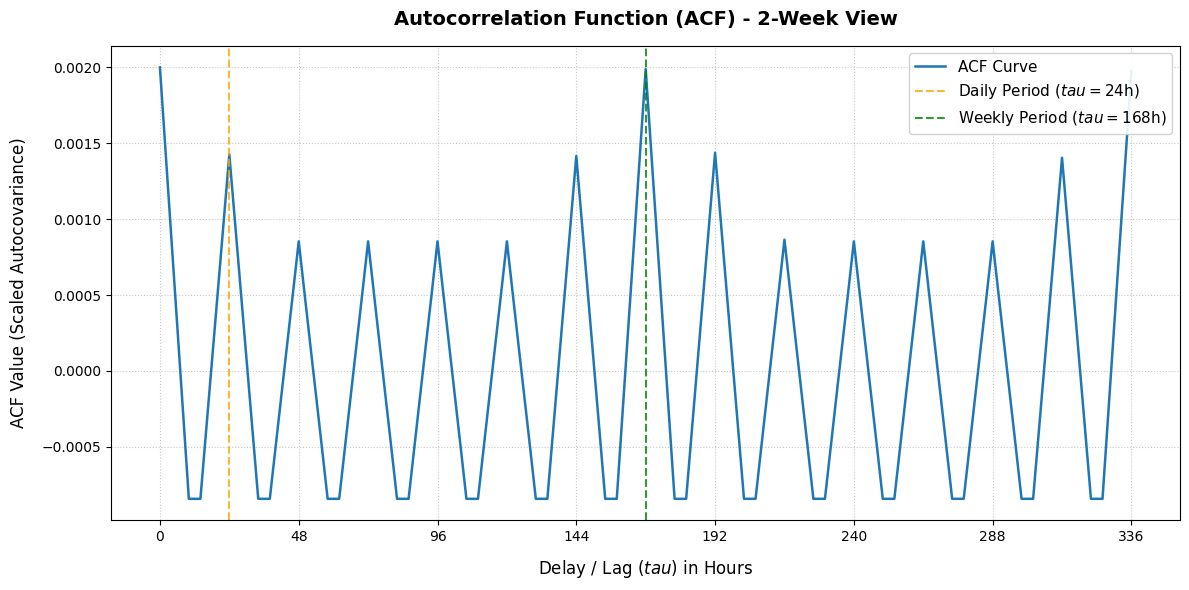

In [61]:
#plot 2: 2-Week View (Zoomed In)
# display ACF on y-axis, time on x-axis
max_tau_2w = 336
taus_2w = list(range(max_tau_2w + 1))
acf_values_2w = [autocorr[t] for t in taus_2w]

plt.figure(figsize=(12, 6))
plt.plot(taus_2w, acf_values_2w, color='#1f77b4', linewidth=1.8, label='ACF Curve')

#highlight daily and weekly periodicities
plt.axvline(x=24, color='orange', linestyle='--', linewidth=1.5, alpha=0.8, label='Daily Period ($\ttau = 24$h)')
plt.axvline(x=168, color='green', linestyle='--', linewidth=1.5, alpha=0.8, label='Weekly Period ($\ttau = 168$h)')

plt.title('Autocorrelation Function (ACF) - 2-Week View', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Delay / Lag ($\ttau$) in Hours', fontsize=12, labelpad=10)
plt.ylabel('ACF Value (Scaled Autocovariance)', fontsize=12, labelpad=10)
plt.xticks(range(0, max_tau_2w + 1, 48))
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(frameon=True, facecolor='white', framealpha=0.9, fontsize=11)
plt.tight_layout()
plt.show()

In [62]:
# write your evaluation function
def autocorr_periodicity(simulated_data):

    if isinstance(simulated_data, pd.DataFrame):
        data_series = simulated_data['combined'].values
    else:
        data_series = simulated_data

    autocorr = autocorrelation(data_series)
    autocorr_dict = autocorr
        
    T = len(autocorr_dict)
    taus = sorted([tau for tau in autocorr_dict.keys() if tau > 0])
    
    #finding all local maxima
    peaks = []
    for i in range(1, len(taus) - 1):
        prev_tau = taus[i - 1]
        curr_tau = taus[i]
        next_tau = taus[i + 1]
        curr_val = autocorr_dict[curr_tau]
        
        if curr_val > autocorr_dict[prev_tau] and curr_val > autocorr_dict[next_tau]:
            peaks.append((curr_tau, curr_val))
            
    #sort all peaks by ACF value descending
    sorted_peaks = sorted(peaks, key=lambda x: x[1], reverse=True)
    
    #if no peaks
    if not sorted_peaks:
        return []

    #this entire next part is for filtering out redundant peaks that are multiples or mirror collisions of previously accepted peaks
    
    #find the primary base period by taking the minimum of the primary peak and its mirror
    primary_curr_tau, _ = sorted_peaks[0]
    primary_base = min(primary_curr_tau, T - primary_curr_tau)
    
    #define a safe threshold to avoid removing mirror collisions
    calendar_remainder = T % primary_base
    safe_threshold = max(primary_base // 4, calendar_remainder * 2)
    
    filtered_peaks = []
    accepted_bases = []

    #taking minimum of current tau and its mirror to avoid duplicates
    for curr_tau, curr_val in sorted_peaks:
        mirror_tau = T - curr_tau
        norm_tau = min(curr_tau, mirror_tau)
        is_redundant = False

        #check if the current tau is a multiple of any previously accepted base or its mirror
        for base in accepted_bases:
            rem_forward = curr_tau % base
            if rem_forward <= 1 or abs(base - rem_forward) <= 1:
                is_redundant = True
                break
            
            #exempt small boundary lags from the mirror collision check
            if norm_tau > safe_threshold:
                rem_mirror = mirror_tau % base
                if rem_mirror <= 1 or abs(base - rem_mirror) <= 1:
                    is_redundant = True
                    break
                
        if not is_redundant:
            filtered_peaks.append((norm_tau, curr_val))
            accepted_bases.append(norm_tau)

    autocorr_periods ={}        
    #returning the filtered peaks as a list of autocorrelation periods
    for tau, val in filtered_peaks:
        autocorr_periods[tau] = val
        
    
    return autocorr_periods

In [63]:
print(autocorr_periodicity(result_df['combined'].tolist()))

{168: 0.001989101347672628, 24: 0.0014268872086416068, 36: -0.0008430506521139123, 204: -0.0008430506521139123, 708: -0.0008430506521139123, 1716: -0.0008430506521139123, 2220: -0.0008430506521139123, 2724: -0.0008430506521139123, 3228: -0.0008430506521139123, 3732: -0.0008430506521139123}


## 3rd part: Periodograms
Take an existing periodogram function from a python packaged (for example Scipy) and run it on the simulated data. Does your evaluation function from the 2nd part similar to the results of the periodogram? 

Generate two periodograms:

a) Using only longitude or latitude data

b) Using the combined longitude and latitude data

Explain the difference in findings. Do they have similar periodograms? 

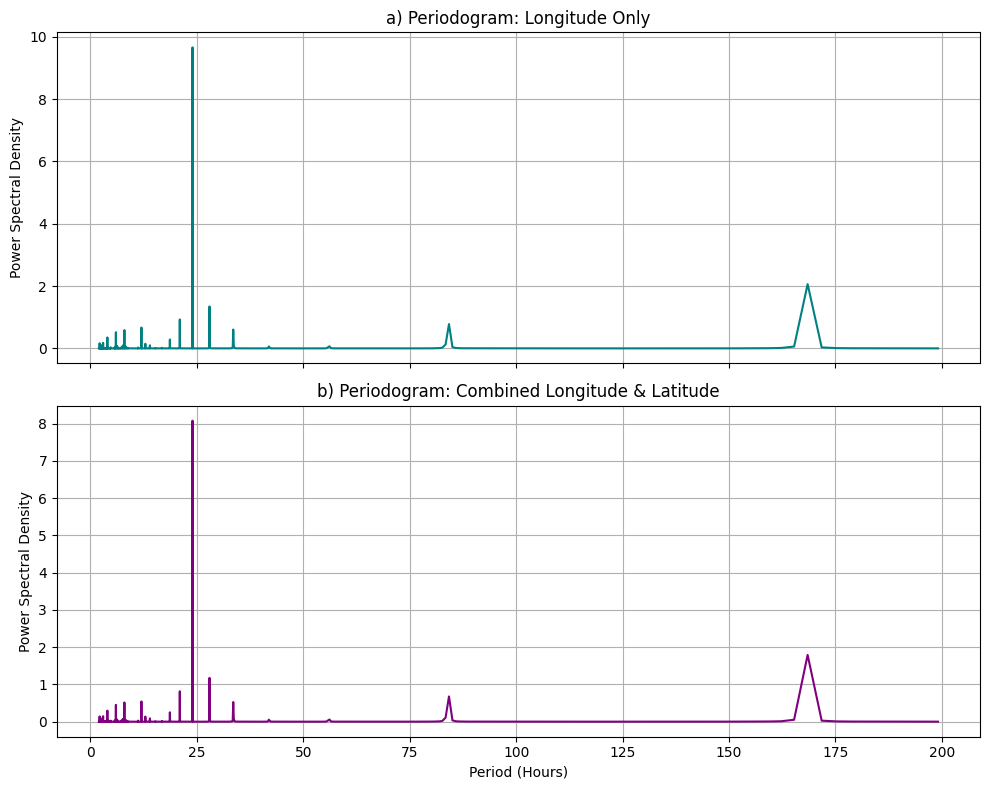

In [ ]:
def generate_periodograms(result_df):
    fs = 1.0 
    lon_data = result_df['longitude'].values 
    combined_data = result_df['combined'].values

    freqs_lon, psd_lon = periodogram(lon_data, fs=fs)
    freqs_comb, psd_comb = periodogram(combined_data, fs=fs)
    
    #convert frequencies to periods in hours
    with np.errstate(divide='ignore'):
        periods_lon = np.where(freqs_lon > 0, 1.0 / freqs_lon, np.inf)
        periods_comb = np.where(freqs_comb > 0, 1.0 / freqs_comb, np.inf)
    
    #plotting
    fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
    max_plot_period = 200
    
    #plot Longitude
    mask_lon = (periods_lon <= max_plot_period) & (periods_lon > 1)
    axes[0].plot(periods_lon[mask_lon], psd_lon[mask_lon], color='teal')
    axes[0].set_title("a) Periodogram: Longitude Only")
    axes[0].set_ylabel("Power Spectral Density")
    axes[0].grid(True)
    
    #plot Combined Data
    mask_comb = (periods_comb <= max_plot_period) & (periods_comb > 1)
    axes[1].plot(periods_comb[mask_comb], psd_comb[mask_comb], color='purple')
    axes[1].set_title("b) Periodogram: Combined Longitude & Latitude")
    axes[1].set_xlabel("Period (Hours)")
    axes[1].set_ylabel("Power Spectral Density")
    axes[1].grid(True)
    
    plt.tight_layout()
    plt.show()

generate_periodograms(result_df)

In [ ]:
def periodogram_periodicity(simulated_data):
    fs = 1.0
    periodogram_periods = {}
    
    columns_to_evaluate = ['longitude', 'combined']
    
    for col in columns_to_evaluate:
        if col not in simulated_data.columns:
            continue
            
        #compute periodogram
        data = simulated_data[col].values
        freqs, psd = periodogram(data, fs=fs)
        
        #convert frequencies to periods in hours
        with np.errstate(divide='ignore'):
            periods = np.where(freqs > 0, 1.0 / freqs, np.inf)
            
        #filter valid range
        mask = (periods > 1) & (periods <= 8760)
        valid_periods = periods[mask]
        valid_psd = psd[mask]
        
        #find dominant peaks
        peaks, _ = find_peaks(valid_psd, prominence=np.max(valid_psd) * 0.05)

        #create dictonary of periods and their corresponding PSD values sorted by PSD descending
        if len(peaks) > 0:
            peak_periods = valid_periods[peaks]
            peak_powers = valid_psd[peaks]
            col_dict = {int(round(p)): float(val) for p, val in zip(peak_periods, peak_powers)}
            sorted_col_dict = dict(sorted(col_dict.items(), key=lambda item: item[1], reverse=True))
            
            periodogram_periods[col] = sorted_col_dict
        else:
            periodogram_periods[col] = {}
            
    return periodogram_periods

In [68]:
print(periodogram_periodicity(result_df))

{'longitude': {24: 9.657701335478595, 168: 2.060682794884988, 28: 1.3455692269350599, 21: 0.9285689338486675, 84: 0.7784758157687827, 12: 0.6689218411080947, 34: 0.6040942642862254, 8: 0.5866972622519421, 6: 0.5184406143044541}, 'combined': {24: 8.077457834344692, 168: 1.791230406791665, 28: 1.1755503880449003, 21: 0.8155257574919186, 84: 0.6769387934201347, 12: 0.5425862762968536, 34: 0.5268459244606987, 8: 0.515222147937989, 6: 0.45053524465165484}}


**Explaination**

1. ACF vs. Periodogram: The baseline results show the differences between each method. The Periodogram ranks the 24-hour cycle highest (~8.08–9.66) because it measures spatial energy and amplitude.ACF ranks the 168-hour cycle highest (0.002 vs. 0.0014), because it measures time-lagged linear consistency.
The minor secondary peaks (36h for ACF, 28h for the Periodogram) are likely sub-harmonics unique to each method's domain (time versus frequency), but they show much lower significance.

2. Periodogram 'longitude' vs 'combined': Both metrics show the same core periodicities (24h and 168h).Longitude shows a higher spectral power (9.66 vs. 8.07 at 24h) likely because the single spatial axis isolates a stronger directional movement (like a clear East-West commute path). The combined metric aggregates multiple dimensions together and with that slightly averages out the variance and slightly weaknes the peak power.

It might be difficult to find all the correct dominant peaks so we will be lenient in grading if we can see that the code is correct.

## 4th part: Performance

Noise in the data can have different causes:

- Missing measurements at different proportions (randomly or in bursts).
- Noise around the location data. Let's assume your GPS sensor has an approximate range of 50 meters, and noisy points (being 100s of meters away) occur occasionaly due to the cloud cover or the multipath affect of the GPS signal.
- Noise around the temporal data. For example, you assume that you leave home everyday at 8 and return at 5, but you might actually leave a bit earlier or a bit later.
- Irregular behavior by skipping or adding a trajectory. For example, going to school on a saturday or skipping groceries for a week. You can also define a number of new places and paths and add them to the trajectory randomly (e.g. going to the cinema every month with some probability)

Choose at least two noise sources, add them to your simulated data and compare the performance of your ACF and periodogram function. Parametrize your process of injecting these noises according to a rate and check how sensitive your algorithms are to different proportions of these sources of imperfections. Which one performs best? Under what circumstances?



In [ ]:
# rate has a value in [0,1] and is used as parameter to define the level of noise added
def add_noise_spatial(data, rate):
    #noise source 1: Spatial GPS Noise & Outliers.
    noisy_data = data.copy()
    
    #base Gaussian noise
    lat_noise = np.random.normal(0, 0.00045 * rate, size=len(noisy_data))
    lon_noise = np.random.normal(0, 0.00045 * rate, size=len(noisy_data))
    
    noisy_data['latitude'] += lat_noise
    noisy_data['longitude'] += lon_noise
    
    #large outlier jumps
    outlier_mask = np.random.rand(len(noisy_data)) < (rate * 0.05)
    if np.any(outlier_mask):
        noisy_data.loc[outlier_mask, 'latitude'] += np.random.choice([-1, 1], size=outlier_mask.sum()) * 0.005
        noisy_data.loc[outlier_mask, 'longitude'] += np.random.choice([-1, 1], size=outlier_mask.sum()) * 0.005

    if 'combined' in noisy_data.columns:
        noisy_data['combined'] = (noisy_data['latitude']**2 + noisy_data['longitude']**2)**0.5
        
    return noisy_data

In [ ]:
def add_noise_irregular(data, rate):
    """
    Noise Source 2: Irregular Behavior (Schedule disruption).
    - rate (0 to 1): Controls the probability that any given weekday schedule 
      is disrupted (e.g., staying home instead of going to Snellius, or taking random trips).
    """
    noisy_data = data.copy()
    
    days = noisy_data.index.normalize().unique()
    
    #selection of days to disrupt based on the rate
    num_disrupted_days = int(len(days) * rate)
    disrupted_days = np.random.choice(days, size=num_disrupted_days, replace=False)
    
    #overwrite work hours to look like "home"
    home_lat = noisy_data['latitude'].iloc[0]
    home_lon = noisy_data['longitude'].iloc[0]
    
    for day in disrupted_days:
        day_mask = (noisy_data.index.normalize() == day)
        hour_mask = (noisy_data.index.hour >= 8) & (noisy_data.index.hour <= 17)
        target_mask = day_mask & hour_mask
        
        noisy_data.loc[target_mask, 'latitude'] = home_lat
        noisy_data.loc[target_mask, 'longitude'] = home_lon
        
    if 'combined' in noisy_data.columns:
        noisy_data['combined'] = (noisy_data['latitude']**2 + noisy_data['longitude']**2)**0.5
        
    return noisy_data


In [ ]:
#helper function to keep output clean by showing only top peaks
def get_top_peaks(result, top_n=3):
    if isinstance(result, dict):
        if any(isinstance(v, dict) for v in result.values()):
            return {col: {k: round(float(v), 4) for k, v in sorted(sub.items(), key=lambda x: x[1], reverse=True)[:top_n]} 
                    for col, sub in result.items()}
        else:
            return {k: round(float(v), 4) for k, v in sorted(result.items(), key=lambda x: x[1], reverse=True)[:top_n]}
    elif isinstance(result, list):
        return result[:top_n]
    return result

#generate noisy datasets
noisy_spatial = add_noise_spatial(result_df, 0.5)
noisy_irregular = add_noise_irregular(result_df, 0.5)

#evaluate
#baseline
acf_clean = autocorr_periodicity(result_df['combined'].tolist())
psd_clean = periodogram_periodicity(result_df)

#spatial noise evaluation
acf_spatial = autocorr_periodicity(noisy_spatial['combined'].tolist() if 'combined' in noisy_spatial else noisy_spatial)
psd_spatial = periodogram_periodicity(noisy_spatial)

#irregular schedule evaluation
acf_irregular = autocorr_periodicity(noisy_irregular['combined'].tolist() if 'combined' in noisy_irregular else noisy_irregular)
psd_irregular = periodogram_periodicity(noisy_irregular)

print("=" * 65)
print("               PERIODICITY CROSS-EVALUATION REPORT               ")
print("=" * 65)

print("\n[BASELINE (CLEAN DATA)]")
print(f"  • ACF (combined)         : {get_top_peaks(acf_clean)}")
print(f"  • Periodogram            : {get_top_peaks(psd_clean)}")

print("\n[TEST 1: SPATIAL NOISE (Rate = 0.5)]")
print(f"  • ACF                    : {get_top_peaks(acf_spatial)}")
print(f"  • Periodogram            : {get_top_peaks(psd_spatial)}")

print("\n[TEST 2: IRREGULAR SCHEDULE (Rate = 0.5)]")
print(f"  • ACF                    : {get_top_peaks(acf_irregular)}")
print(f"  • Periodogram            : {get_top_peaks(psd_irregular)}")

print("=" * 65)

               PERIODICITY CROSS-EVALUATION REPORT               

[BASELINE (CLEAN DATA)]
  • ACF (combined)         : {168: 0.002, 24: 0.0014, 36: -0.0008}
  • Periodogram            : {'longitude': {24: 9.6577, 168: 2.0607, 28: 1.3456}, 'combined': {24: 8.0775, 168: 1.7912, 28: 1.1756}}

[TEST 1: SPATIAL NOISE (Rate = 0.5)]
  • ACF                    : {168: 0.002, 24: 0.0014, 3565: -0.0008}
  • Periodogram            : {'longitude': {24: 9.6612, 168: 2.0573, 28: 1.3459}, 'combined': {24: 8.069, 168: 1.7943, 28: 1.1745}}

[TEST 2: IRREGULAR SCHEDULE (Rate = 0.5)]
  • ACF                    : {1008: 0.0006, 840: 0.0005, 1848: 0.0005}
  • Periodogram            : {'longitude': {24: 2.3601, 168: 0.5947, 28: 0.3882}, 'combined': {24: 1.9726, 168: 0.5163, 28: 0.3389}}


### Conclusion
Write a brief report on your findings (150 words max):

(Write your report here)

## 5th part: Real life data

You will use data from the geolife datasets to test the time-series analysis methods that you developed. Your task is to apply the methods you just learned and interpret the data. 

[Download the data here](https://www.microsoft.com/en-us/download/details.aspx?id=52367). You will find multiple participants' trajectories in the dataset. For this assignment, we will focus on participant **125**.

[The user guide of the entire dataset can be found here](https://www.microsoft.com/en-us/research/wp-content/uploads/2016/02/User20Guide-1.2.pdf).

Use these questions as a guideline for your analysis: 

a) What is the general structure of the data? How much noise do you observe? What is the temporal granularity of your data? How long did your participant log their movement? 


b) Do you see any missing recordings if you create the time-series like the one you simulated? Can you try to find a way to fill in the missing values in the time series of both coordinates?


c) Apply Autocorrelation (your own from Section I) and periodogram. Did you find periodic behaviors? What are the periodicities? Briefly summarize your observations in conclusion below (max 100 words).


d) If you cannot identify periodic behaviors: Can you mention why? What makes your data challenging? What realistic aspect of data is missing in your simulation? Having these challenges in mind what would be your topmost priorities, if you were to design a data collection protocol? Please explain in the conclusion below (max 200 words)





In [72]:
# import data


In [73]:
# handle missing values


In [74]:
# run (your own) ACF


In [75]:
# run periodogram on the data


### Conclusion 

All observations related to questions (a–d) are expected to be included in the Conclusion (350 words max).

## How do we grade this assignment?
Please pay attention to the following points. We consider these in calculating your final grade.

First of all, please check if you have pushed this notebook to the GitHub classroom before the deadline. You can check online on the GitHub classroom if the most up to date version of your code is present there, we can't grade your notebook if it is not there! **Make sure to read the *"Submission procedure"* section in the *"README.md"* file to ensure reproducibility.**

**1st part:**

1.   Your simulated data should have latitude and longitude.
2.   Your simulated data should have the correct dimensionality/frequency.
2.   It should also have both a daily and weekly cycle.



**2nd part:**


1. You should have correctly implemented the autocorrelation function.
2. We consider the graphs generated in grading.
3. We consider if the function returns 2 periodic cycles correctly.
4. We consider the extraction of the more prominent cycle. 



**3rd part:**

1.   We consider the implementation of the function based on periodogram.
2.   We consider if you applied periodogram on both types of data i.e longitude/latitude , combined one (latitude and longitude) and explain your findings.


**4th part:**
1. We consider if two noise sources are added.
2. We check if both autocorrelation and periodogramd are applied to data.
3. We check if the results of the experiments are presented in a useful way.
4. We check the conclusions.


**5th part:**
1. We check if you have explored data.
2. We check if you tried to handle missing values if any.
2. We check if you have used periodogram and autocorrelation function.
3. We check your Conclusion